## Test the rearangemenet of xs 

In [23]:
import csv
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from multiprocessing import Pool
from vista_utils_ARM import *
import shutil
import os
def reset_folder(folder_path):
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path) 
    os.makedirs(folder_path)  

In [24]:
def plot_first_traces(trace_items, title, max_traces, save_path=None):
    plt.close("all")
    plt.figure(figsize=(30, 6))

    for k, (run_index, xs_id, trace) in enumerate(trace_items[:max_traces]):
        plt.plot(trace, alpha=0.7, label=f"{k}: run={run_index}, xs={xs_id}")

    plt.title(title)
    plt.xlabel("Instruction index")
    plt.ylabel("Leakage value")
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200)

    plt.show()

In [25]:
def HW(a):
    return a.count('1')

def HD(a,b):
#     print(type(sum(c1 != c2 for c1, c2 in zip(a, b)) ))
    return sum(c1 != c2 for c1, c2 in zip(a, b)) 

def hex_to_bin32(x):
    return bin(int(x, 0))[2:].rjust(32, '0')

def create_HD_trace(filename, cols):
    df = pd.read_csv(filename)
    df.fillna('0x0', inplace=True)

    reg_bin = []
    for col in cols:
        reg_bin.append(df[col].apply(hex_to_bin32).tolist())

    number_instructions = len(reg_bin[0])
    hd_ref = np.zeros((number_instructions - 1, len(cols)))

    for col in range(len(cols)):
        for i in range(number_instructions - 1):
            hd_ref[i, col] = HD(reg_bin[col][i], reg_bin[col][i + 1])

    return np.sum(hd_ref, axis=1)


def create_HW_trace(filename,cols):
      """
      reads an execution trace in csv format 
      returns 
      - the hamming weight of  the content of all registers for each instruction
      - the total number of instructions

      """
      df = pd.read_csv(filename)
      df.fillna('0x0', inplace=True)
      #cols = ['zero', 'ra', 'sp', 'gp', 'tp', 't0', 't1','t2', 's0', 's1', 'a0', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 's2',
      #  's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 't3', 't4','t5', 't6']
     #cols = ['t1', 's0', 'a0', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 't3']
      # convert hex register values to binary and decimal values
      reg_bin=[]
      for col in cols:
          reg_bin.append(df[col].apply(hex_to_bin32).tolist())

      number_instructions = len(reg_bin[0])# number of instructions
      hw_ref = np.zeros((number_instructions ,len(cols)))
      for col in range(len(cols)):
        for i in range(number_instructions):
            hw_ref[i,col] = HW(reg_bin[col][i])
      return  np.sum(hw_ref,axis=1)





In [26]:
def create_npy_file_truncated(name_npy_file, folder, leakage_model, no_printed_traces, cols, debug_plot_dir=None):
    def parse_trace_name(path):
        match = re.match(r"trace_(\d+)_(\d+)\.csv$", path.name)
        if match is None:
            return None

        run_index = int(match.group(1))
        xs_id = int(match.group(2))
        return run_index, xs_id

    print("Creating simulation traces model....", leakage_model)

    files_raw = []

    for file in Path(folder).glob("trace_*_*.csv"):
        parsed = parse_trace_name(file)
        if parsed is None:
            continue

        run_index, xs_id = parsed
        files_raw.append((run_index, xs_id, file))

    print(f"Found {len(files_raw)} truncated trace files")

    # BEFORE rearrangement
    files_before = sorted(files_raw, key=lambda x: (x[0], x[1]))

    traces_before = []

    for count, (run_index, xs_id, file) in enumerate(files_before):
        if count % 100 == 0:
            print(f"Trace {count} has been converted")

        if leakage_model == "HW":
            trace = create_HW_trace(file, cols)
        elif leakage_model == "HD":
            trace = create_HD_trace(file, cols)
        else:
            raise ValueError("leakage_model must be 'HW' or 'HD'")

        traces_before.append((run_index, xs_id, trace))

    # AFTER rearrangement
    traces_after = sorted(traces_before, key=lambda x: (x[1], x[0]))

    if debug_plot_dir is not None:
        os.makedirs(debug_plot_dir, exist_ok=True)
        plot_first_traces(traces_before,title=f"{leakage_model}: first 8 traces BEFORE rearranging",max_traces=no_printed_traces,save_path=os.path.join(debug_plot_dir, f"{leakage_model}_before_rearranging.png"))
        plot_first_traces(traces_after,title=f"{leakage_model}: first 8 traces AFTER rearranging by xs",max_traces=no_printed_traces,save_path=os.path.join(debug_plot_dir, f"{leakage_model}_after_rearranging.png"))

    traces_by_xs = {xs_id: [] for xs_id in range(8)}

    for run_index, xs_id, trace in traces_after:
        traces_by_xs[xs_id].append(trace)

    for xs_id in range(8):
        min_len = min(len(t) for t in traces_by_xs[xs_id])
        vectors_array = np.array([t[:min_len] for t in traces_by_xs[xs_id]])

        npy_name = f"{name_npy_file}_xs{xs_id}.npy"
        np.save(npy_name, vectors_array)

        print(f"Saved {npy_name}, shape = {vectors_array.shape}")

    print("Finished creating truncated npy files")

    return traces_before, traces_after, traces_by_xs

Creating simulation traces model.... HW
Found 640 truncated trace files
Trace 0 has been converted
Trace 100 has been converted
Trace 200 has been converted
Trace 300 has been converted
Trace 400 has been converted
Trace 500 has been converted
Trace 600 has been converted


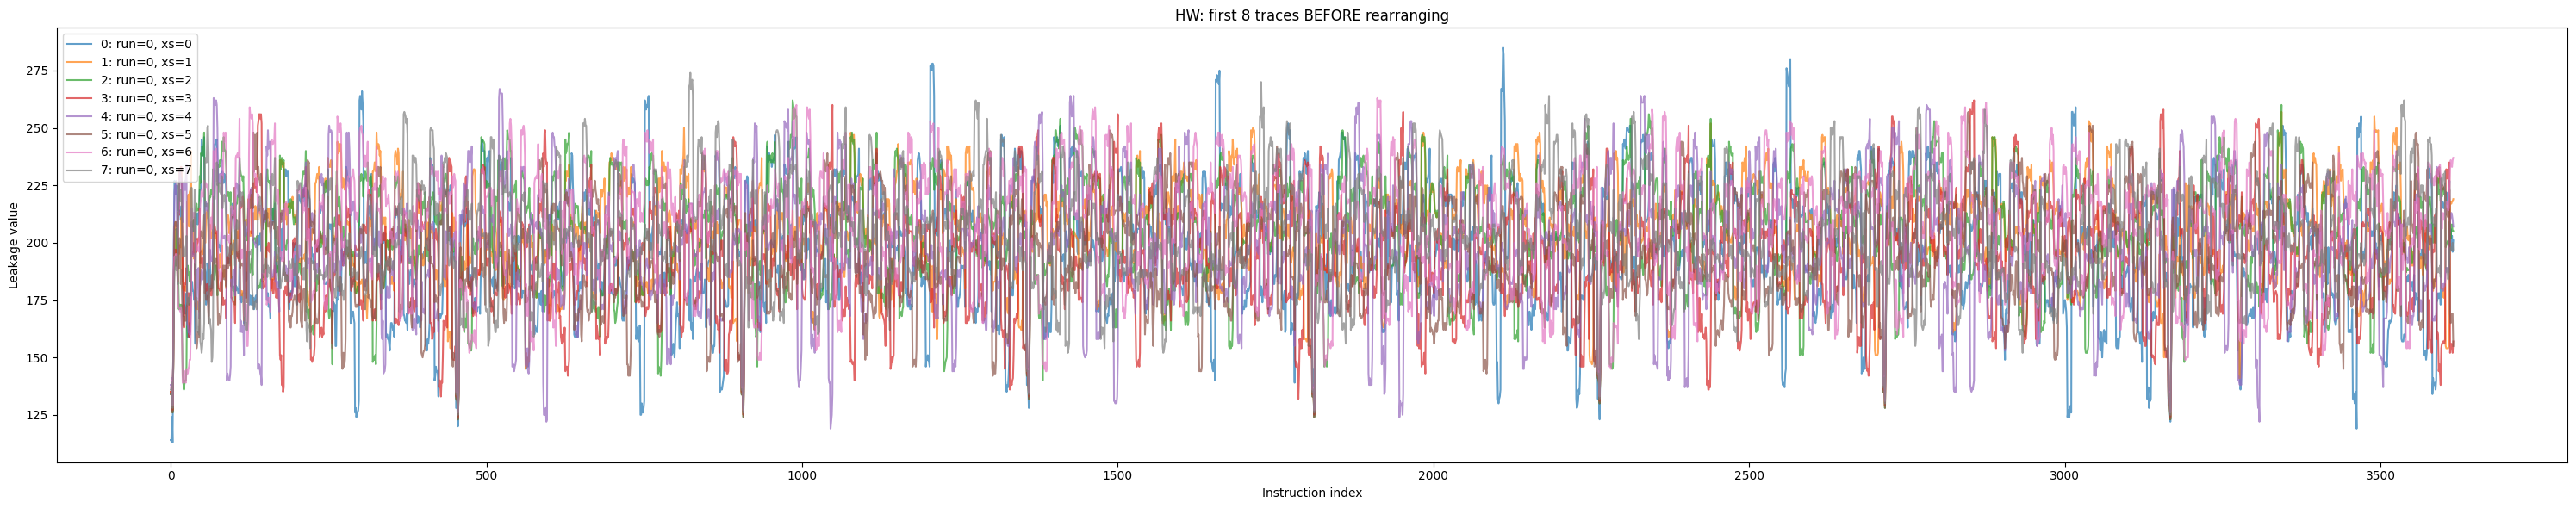

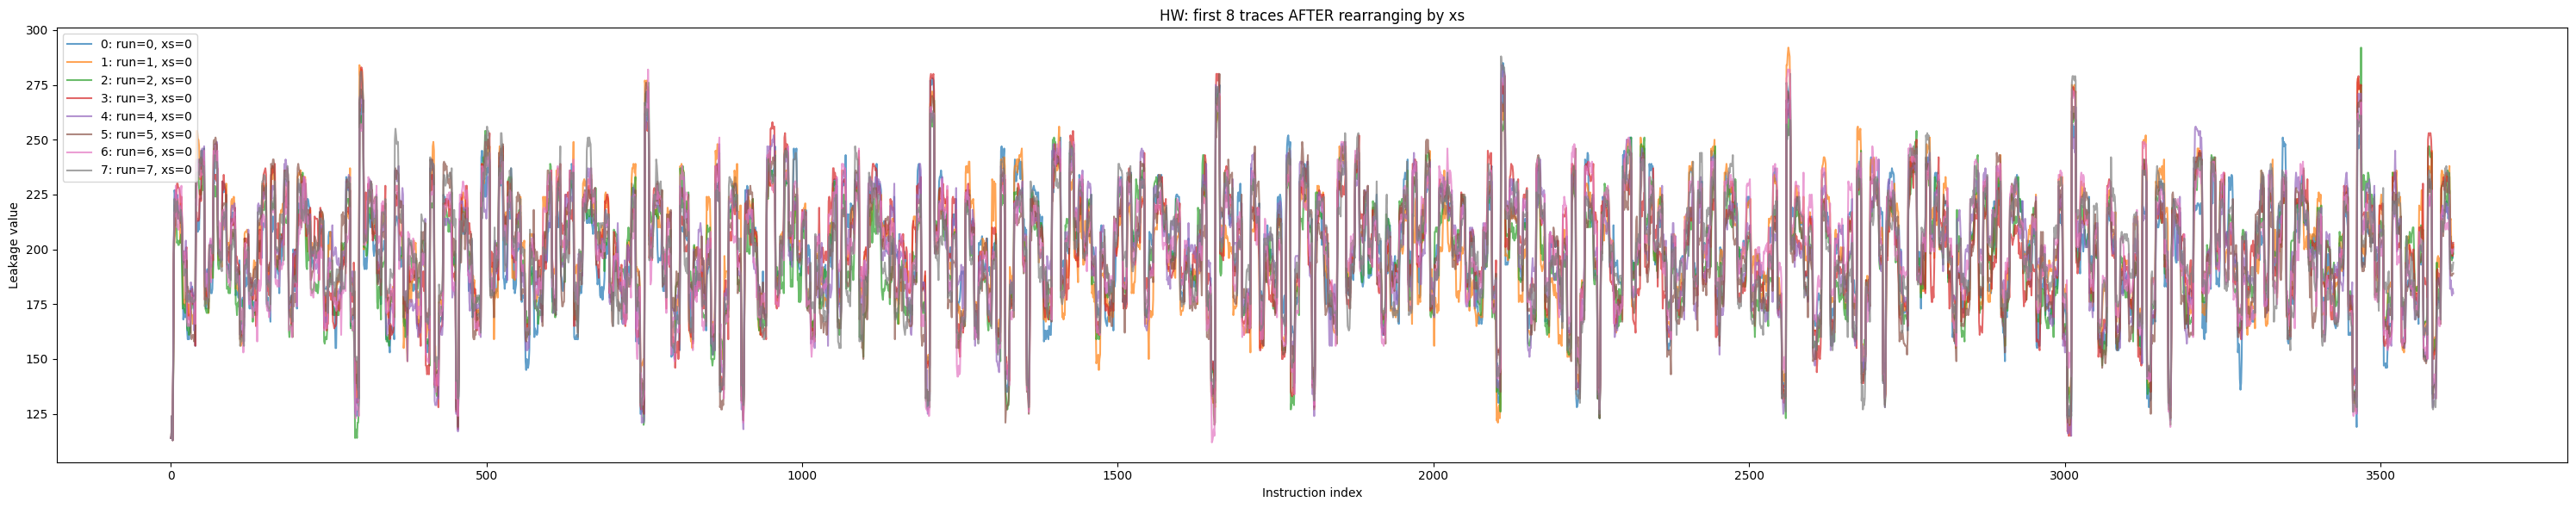

Saved Results_truncated_test/HW_SUBTRACE_xs0.npy, shape = (80, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs1.npy, shape = (80, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs2.npy, shape = (80, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs3.npy, shape = (80, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs4.npy, shape = (80, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs5.npy, shape = (80, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs6.npy, shape = (80, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs7.npy, shape = (80, 3616)
Finished creating truncated npy files
Creating simulation traces model.... HD
Found 640 truncated trace files
Trace 0 has been converted
Trace 100 has been converted
Trace 200 has been converted
Trace 300 has been converted
Trace 400 has been converted
Trace 500 has been converted
Trace 600 has been converted


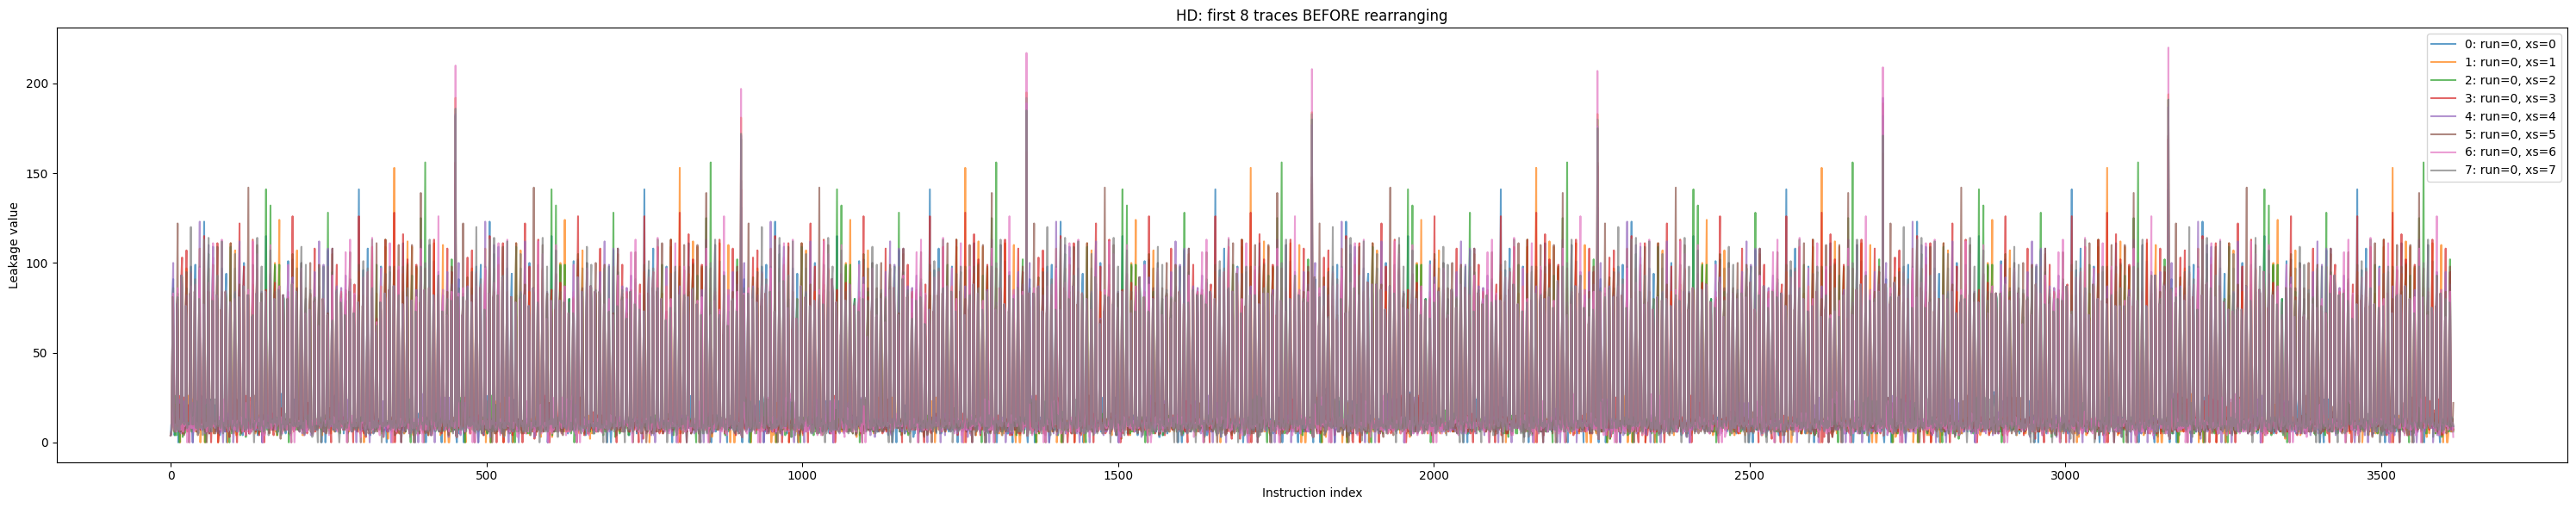

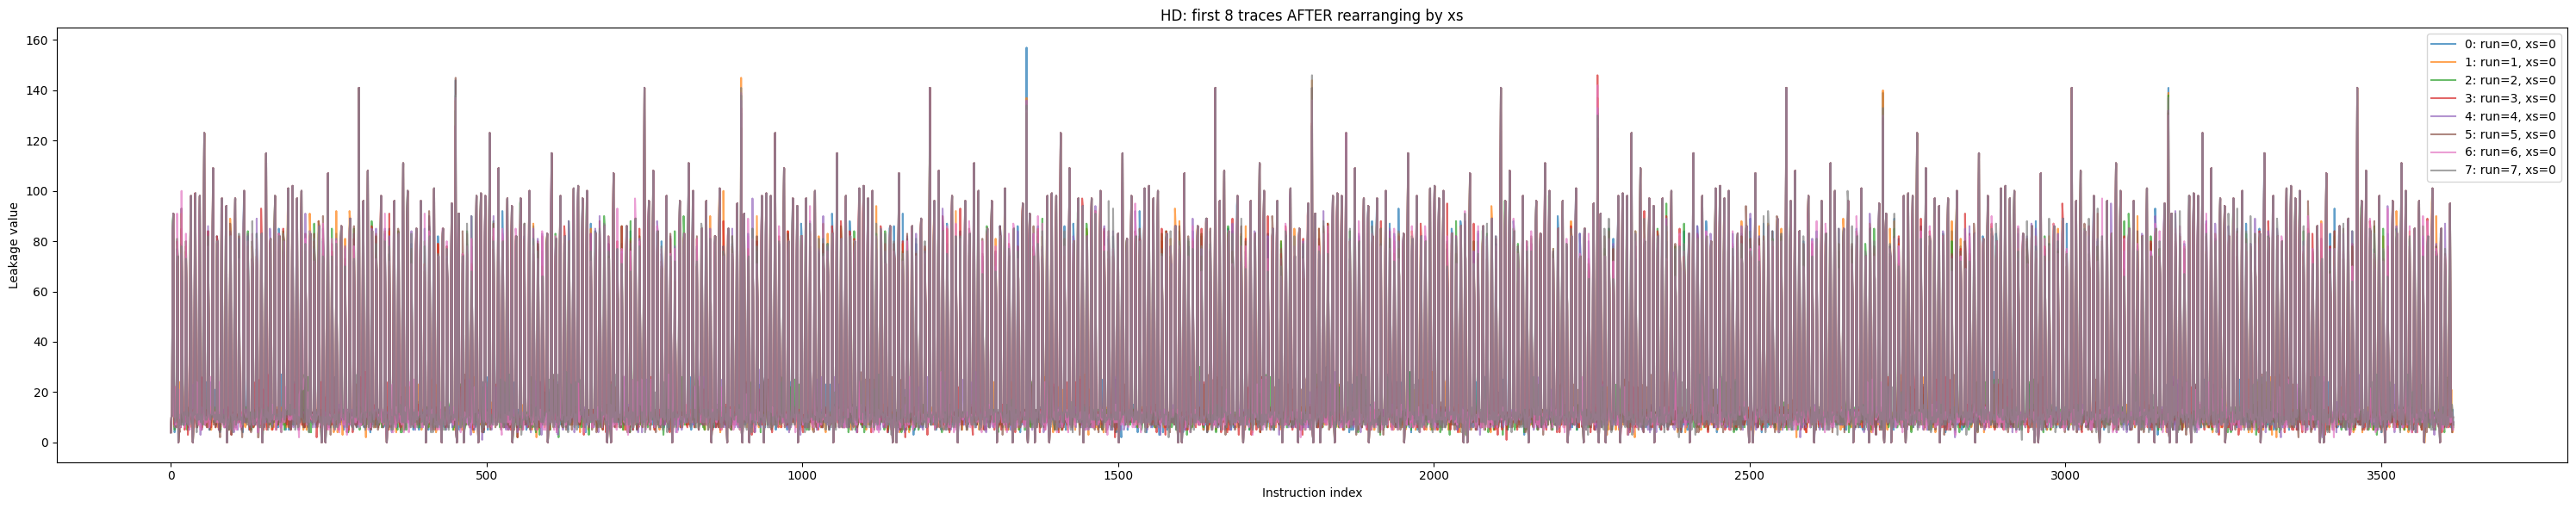

Saved Results_truncated_test/HD_SUBTRACE_xs0.npy, shape = (80, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs1.npy, shape = (80, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs2.npy, shape = (80, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs3.npy, shape = (80, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs4.npy, shape = (80, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs5.npy, shape = (80, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs6.npy, shape = (80, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs7.npy, shape = (80, 3615)
Finished creating truncated npy files


In [27]:
os.makedirs("Results_truncated_test", exist_ok=True)
result_dir_truncated = "Results_truncated_test"
folder = "output_decapsulation_truncated_TRIM"
selected_registers= ['r0','r1','r2','r3','r4','r5','r6','r7','r8','r9','r10','r11','r12','sp','lr']

filename_hw = f"{result_dir_truncated}/HW_SUBTRACE"
no_printed_traces = 8
hw_before, hw_after, hw_by_xs = create_npy_file_truncated(
    filename_hw,
    folder,
    "HW",
    no_printed_traces,
    selected_registers,
    debug_plot_dir=result_dir_truncated
)

filename_hd = f"{result_dir_truncated}/HD_SUBTRACE"

hd_before, hd_after, hd_by_xs = create_npy_file_truncated(
    filename_hd,
    folder,
    "HD",
    no_printed_traces,
    selected_registers,
    debug_plot_dir=result_dir_truncated
)